# Topic 18: Frequency Response Parameters

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [62]:
colors = bm.get_colors()
j = complex(0,1)

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

import control as ct
import control.matlab as cmat

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

## Basic Bode Plot

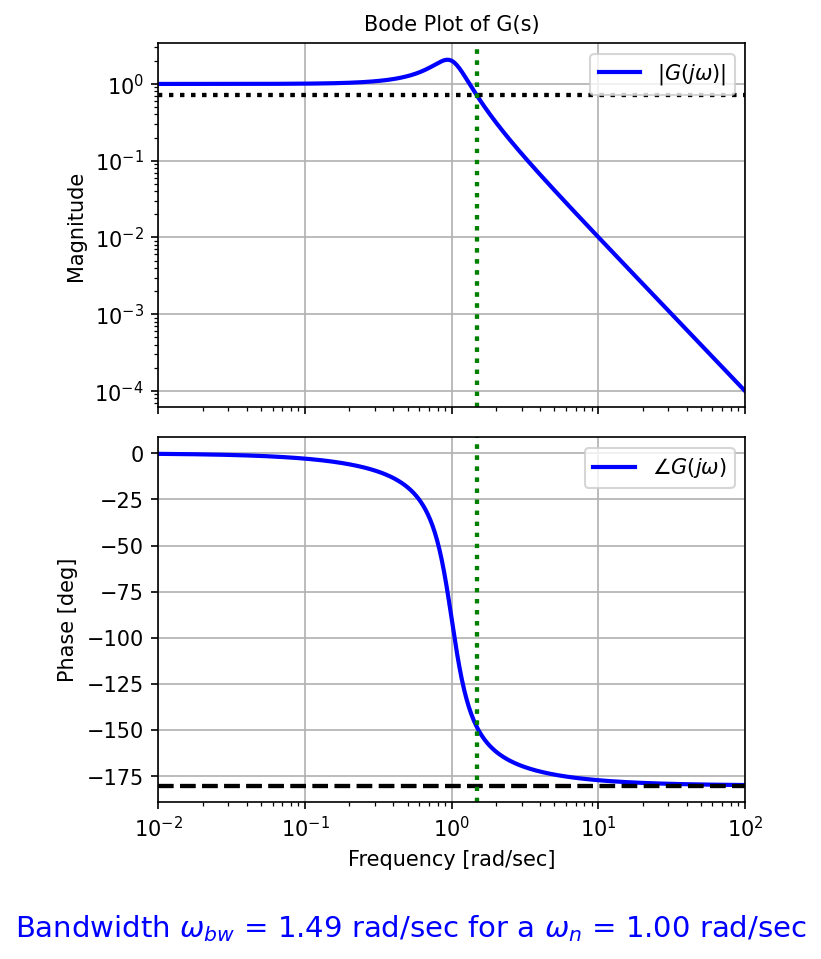

In [63]:
fig, ax = plt.subplots(2,1,figsize=(5, 6),dpi=150,sharex=True)
omega_n = 1
zeta = 0.25
w = np.logspace(-2,2,500)

mag_red_for_wb = 1/np.sqrt(2)

G = ct.tf([omega_n**2],[1, 2*zeta*omega_n, omega_n**2]) 
Gfreq = G(j*w)
Gm, Gp = np.abs(Gfreq), cm.pshift(np.angle(Gfreq))*cm.r2d
# Bandwidth calc - freq when is magnitude 0.7071?
wb = cm.find_wc(w,G,mag_red_for_wb)

ax[0].loglog(w,Gm,'b-',label=r'$|G(j\omega)|$')
ax[0].axhline(y=mag_red_for_wb,c='k',ls=":")
ax[0].axvline(x=wb[0],c='g',ls=":")
ax[0].set_ylabel("Magnitude")
ax[0].set_title("Magnitude Plot")
ax[0].legend()
ax[1].semilogx(w,Gp,'b-',label=r'$\angle G(j\omega)$')
ax[1].axhline(y=-180,c='k',ls="--")
ax[1].axvline(x=wb[0],c='g',ls=":")
ax[1].set_xlabel("Frequency [rad/sec]")
ax[1].set_ylabel("Phase [deg]")
ax[1].legend()

ax1,ax2 = plt.gcf().axes
ax1.set_title("Bode Plot of G(s)")
ax1.axhline(y=1/np.sqrt(2),c='k',ls=":")
ax2.axhline(y=-180,c='k',ls="--")
ax1.axvline(x=wb[0],c='g',ls=":")
ax2.axvline(x=wb[0],c='g',ls=":")
cm.caption(r"Bandwidth $\omega_{{bw}}$ = {:4.2f} rad/sec for a $\omega_n$ = {:4.2f} rad/sec".format(wb[0],omega_n),fig)

# How does the $\omega_c$ and PM depend on $\zeta$?

Consider 
$$
G(s) = \frac{\omega_n^2}{s^2 + 2\zeta \omega_ns + \omega_n^2}
$$
can rewrite this as the unity feedback of the loop 
$ \displaystyle L(s) = \frac{\omega_n^2}{s(s+2\zeta \omega_n)}$ since then
$$
\frac{L}{1+L} = \left(\frac{\omega_n^2}{s(s+2\zeta \omega_n)}\right) / \left(1+\frac{\omega_n^2}{s(s+2\zeta \omega_n)}\right) = \frac{\omega_n^2}{s^2 + 2\zeta \omega_ns + \omega_n^2}
$$

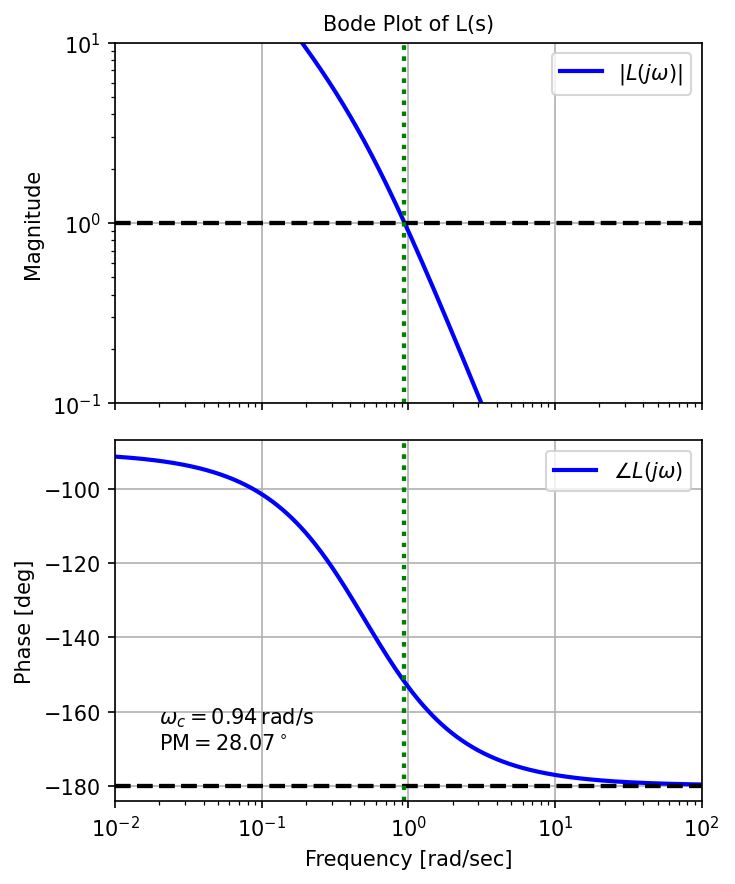

In [64]:
fig, ax = plt.subplots(2,1,figsize=(5, 6),dpi=150,sharex=True)
L = ct.tf([omega_n**2],[1, 2*zeta*omega_n, 0]) 
Lfreq = L(j*w) #[Gm Gp Gw]
Lm, Lp = np.abs(Lfreq), cm.pshift(np.angle(Lfreq))*cm.r2d
PM,wc,_ = cm.find_PM(w,Lfreq)

ax[0].loglog(w,Lm,'b-',label=r'$|L(j\omega)|$')
ax[0].axhline(y=1,c='k',ls="--")
ax[0].axvline(x=wc,c='g',ls=":")
ax[0].set_ylabel("Magnitude")
ax[0].set_title("Magnitude Plot")
ax[0].legend()
ax[1].semilogx(w,Lp,'b-',label=r'$\angle L(j\omega)$')
ax[1].axhline(y=-180,c='k',ls="--")
ax[1].axvline(x=wc,c='g',ls=":")
ax[1].set_xlabel("Frequency [rad/sec]")
ax[1].set_ylabel("Phase [deg]")
ax[1].legend()

ax1,ax2 = plt.gcf().axes
ax1.axhline(y=1,c='k',ls="--")
ax1.set_ylim([.1,10])
ax1.set_title("Bode Plot of L(s)")
ax2.axhline(y=-180,c='k',ls="--")
ax1.axvline(x=wc,c='g',ls=":")
ax2.axvline(x=wc,c='g',ls=":")
ax2.text(min(w)*2, -170, f"$\\omega_c = {wc:.2f}\\,\\mathrm{{rad/s}}$\n$\\mathrm{{PM}} = {PM:.2f}^\\circ$", fontsize=10)
plt.show()

### Bandwdith Frequency

Compute the magnitude of the frequency response of $G(s)$ as
$$ |G(j\omega)| = \frac{1}{\sqrt{(1-(\frac{\omega}{\omega_n})^2)^2 + (\frac{2\zeta\omega}{\omega_n})^2}}
$$
For the frequency of the bandwidth, set this magnitude value to $|G(j\omega_{bw})| \equiv \frac{1}{\sqrt{2}}$

Need to find $\omega$ for which 
$$
(1-(\omega/\omega_n)^2)^2+(2\zeta\omega/\omega_n)^2 = 2
$$
Let
$
x = \frac{\omega}{\omega_n}.
$
to get 
$
(1 - x^2)^2 + (2\zeta x)^2 - 2 = 0.
$
Expanding,
$$
1 - 2x^2 + x^4 + 4\zeta^2 x^2 - 2 = 0,
$$
which simplifies to
$
x^4 + (4\zeta^2 - 2)x^2 - 1 = 0.
$ This is quadratic in $x^2=y$, so
$
y^2 + (4\zeta^2 - 2)y - 1 = 0.
$

Solving analytically,
$$
y = \frac{-(4\zeta^2 - 2) \pm \sqrt{(4\zeta^2 - 2)^2 + 4}}{2}.
$$

Simplifying the discriminant,
$
(4\zeta^2 - 2)^2 + 4 = 16\zeta^4 - 16\zeta^2 + 8
$,
thus
$
y = 1 - 2\zeta^2 \pm \sqrt{4\zeta^4 - 4\zeta^2 + 2}
$

But only the positive root is physically meaningful, so
$$
\boxed{
\frac{\omega_{bw}}{\omega_n}
=
\sqrt{
1 - 2\zeta^2 + \sqrt{4\zeta^4 - 4\zeta^2 + 2}
}
}
$$

### Crossover Frequency

Note that $\omega_c$ occurs when $|L(j\omega_c)|=1$, where $$ L(j\omega) = \frac{\omega_n^2}{\sqrt{\omega^4 + (2\zeta\omega\omega_n)^2}} = \frac{1}{\sqrt{(\omega/\omega_n)^4 + (2\zeta\omega/\omega_n)^2}} $$ 

We need to solve $(\omega/\omega_n)^4 + (2 \zeta \omega/\omega_n)^2 - 1 = 0$, so let 
$x = \dfrac{\omega}{\omega_n}$, and
the equation becomes
$$x^4 + 4\zeta^2 x^2 - 1 = 0.$$

This is quadratic in $x^2 = y$, so that $y^2 + 4\zeta^2 y - 1 = 0$
with solutions
$$
y = -2\zeta^2 \pm \sqrt{4\zeta^4 + 1}.
$$
Only the positive root is physically meaningful, so
$$
y = -2\zeta^2 + \sqrt{4\zeta^4 + 1}.
$$
Undoing the substitution,
$$
\frac{\omega_c}{\omega_n} = \sqrt{-2\zeta^2 + \sqrt{4\zeta^4 + 1}}
$$
Thus the result is that $\displaystyle \frac{\omega_c}{\omega_n} = \sqrt{\sqrt{4\zeta^4 + 1} - 2\zeta^2}$

In [65]:
def f_wc(wn,z):
    return wn*np.sqrt(np.sqrt(4*z**4 + 1) - 2*z**2)
def f_wb(wn,z):
    return wn*np.sqrt(1 - 2*z**2 + np.sqrt(4*z**4 - 4*z**2 + 2))

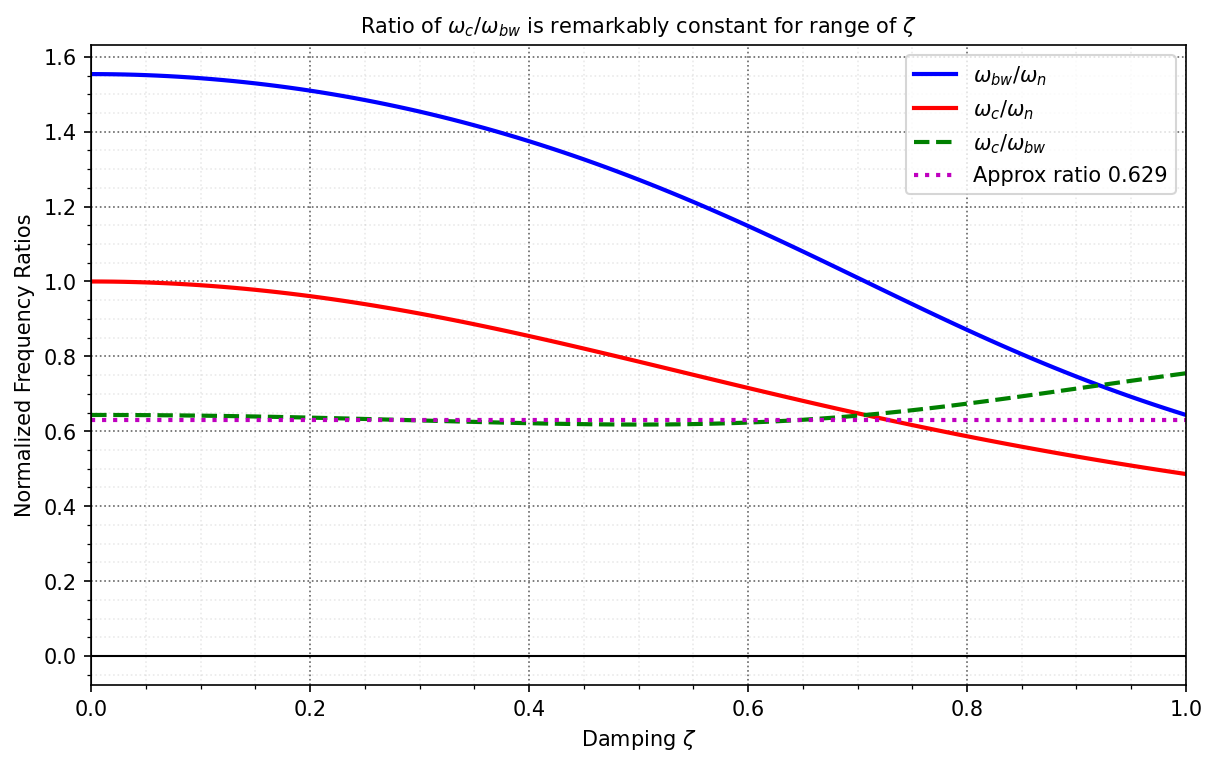

In [74]:
fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
z_range = np.arange(0,1.01,.01)
plt.plot(z_range,f_wb(1,z_range),'b-',label=r"$\omega_{bw}/\omega_n$")
plt.plot(z_range,f_wc(1,z_range),'r-',label=r"$\omega_c/\omega_n$")
plt.plot(z_range,f_wc(1,z_range)/f_wb(1,z_range),'g--',label=r"$\omega_c/\omega_{bw}$")
plt.axhline(y=f_wc(1,0.3)/f_wb(1,0.3),ls=':',color='m',label=r'Approx ratio {:4.3f}'.format(f_wc(1,0.3)/f_wb(1,0.3)))
plt.legend()
bm.nicegrid(ax)
ax.set_ylabel("Normalized Frequency Ratios")
plt.xlabel(r"Damping $\zeta$")
ax.set_title(r"Ratio of $\omega_c/\omega_{bw}$ is remarkably constant for range of $\zeta$ ")
plt.show()

Now consider the phase margin $\phi_m$ at $\omega_c$
$$
\phi_m = 180 - \arctan\left( \frac{2\zeta\omega_n}{-\omega_c} \right) = 180 - \left(180 - \arctan\left( \frac{2\zeta\omega_n}{\omega_c} \right)\right) = \arctan\left( \frac{2\zeta\omega_n}{\omega_c} \right)
$$
where from above, $\displaystyle \frac{\omega_c}{\omega_n} = \sqrt{\sqrt{4\zeta^4 + 1} - 2\zeta^2}$ so
$$
\phi_m = \arctan\left( \frac{2\zeta}{\sqrt{\sqrt{4\zeta^4 + 1} - 2\zeta^2}} \right)
$$


In [78]:
def f_rm(zz): 
    return np.arctan(2*zz/np.sqrt(np.sqrt(4*zz**4+1)-2*zz**2))*180/np.pi

z_range = np.arange(0,0.707,.01)
pm = f_rm(z_range)

k_opt = np.dot(pm, z_range) / np.dot(z_range, z_range)

from IPython.display import display, Latex
display(Latex(rf'Optimal PM linear fit = {k_opt:6.2f} $\zeta$'))

<IPython.core.display.Latex object>

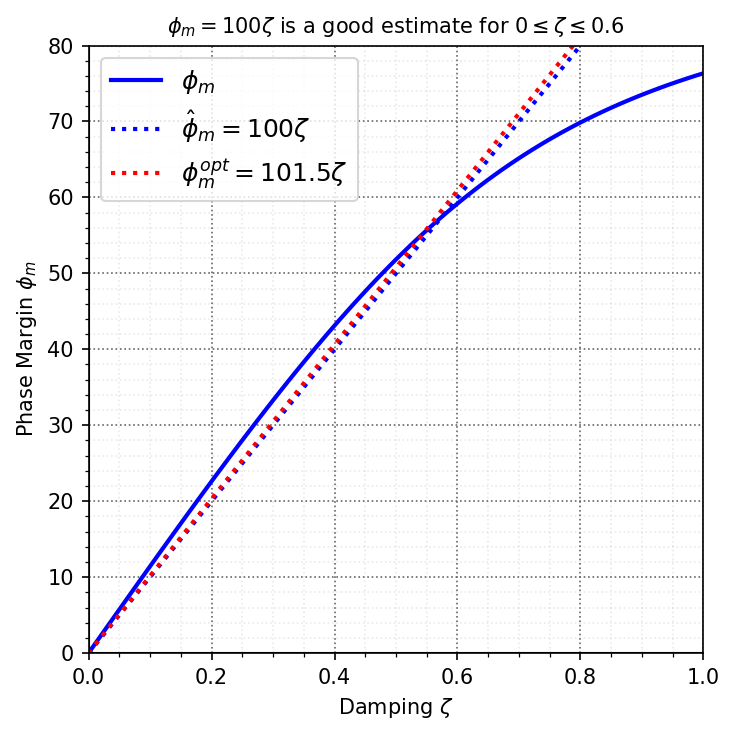

In [79]:
fig, ax = plt.subplots(1,figsize=(5, 5),dpi=150)
z_range = np.arange(0,1.01,.01)
plt.plot(z_range,f_rm(z_range),'b-',label=r"$\phi_m$")
plt.plot([0,1.0],[0,100],'b:',label=r"$\hat \phi_m = 100 \zeta$")
plt.plot([0,1.0],[0,k_opt],'r:',label=r"$\phi_m^{{opt}} = {:5.1f} \zeta$".format(k_opt))
plt.ylim([0,80])
bm.nicegrid(ax)
plt.legend(fontsize=12)
plt.xlabel(r"Damping $\zeta$")
plt.ylabel(r"Phase Margin $\phi_m$")
ax.set_title(r"$\phi_m = 100 \zeta$ is a good estimate for $0\leq \zeta \leq 0.6$")
plt.savefig("./figs/PM_approx.pdf", dpi=600)
plt.show()

### Peak of Response

To find the peak in the frequency response, set $d|G(j\omega)|/d \omega = 0$
With $
x = \dfrac{\omega}{\omega_n}.
$
the squared denominator of the magnitude is
$$
D(x) = (1 - x^2)^2 + (2\zeta x)^2.
$$
which expands to:
$$
D(x) = 1 - 2x^2 + x^4 + 4\zeta^2 x^2
     = x^4 + (4\zeta^2 - 2)x^2 + 1.
$$
To find the peak magnitude, minimize $D(x)$ via
$
\dfrac{dD}{dx}
= 4x^3 + 2(4\zeta^2 - 2)x.
$

Set the derivative equal to zero:
$$
4x^3 + 2(4\zeta^2 - 2)x = 2x \left( 2x^2 + 4\zeta^2 - 2 \right) = 0.
$$

The solutions are:
$
x = 0
$
and
$
x^2 = 1 - 2\zeta^2,
$
and the nonzero solution gives the peak frequency. Thus, the frequency of the resonant peak is
$$
\boxed{
\dfrac{\omega_r}{\omega_n} =  \sqrt{1 - 2\zeta^2}
}
$$

With the normalized variable
$
x=\dfrac{\omega}{\omega_n}$, 
$|G(j\omega)|=\dfrac{1}{\sqrt{(1-x^2)^2+(2\zeta x)^2}}.
$

Evaluate the squared denominator at 
$x_r=\sqrt{1-2\zeta^2}$. Since $1-x_r^2=2\zeta^2$ and $x_r^2=1-2\zeta^2$,
$$
\begin{aligned}
D(x_r)
&=(1-x_r^2)^2+(2\zeta x_r)^2
=(2\zeta^2)^2 + 4\zeta^2(1-2\zeta^2) \\
&=4\zeta^4 + 4\zeta^2 - 8\zeta^4
=4\zeta^2(1-\zeta^2).
\end{aligned}
$$
Therefore the peak magnitude (the resonant peak) is
$$
M_r \equiv |G(j\omega_r)| = \frac{1}{\sqrt{D(x_r)}} = \frac{1}{2\zeta\sqrt{1-\zeta^2}}.
$$

**Remarks / edge cases**

- The resonant peak exists only when $ \zeta < 1/\sqrt{2}$. For $\zeta \ge 1/\sqrt{2}$ there is no resonance  

In [69]:
def f_peak(wn, z):
    wn = np.asarray(wn, dtype=float)
    z = np.asarray(z, dtype=float)

    # broadcast to common shape
    wn, z = np.broadcast_arrays(wn, z)

    # resonance condition
    mask = z < 1 / np.sqrt(2)

    wr = np.full_like(z, np.nan, dtype=float)
    Mr = np.full_like(z, np.nan, dtype=float)

    # compute only where resonance exists
    wr[mask] = wn[mask] * np.sqrt(1 - 2*z[mask]**2)
    Mr[mask] = 1.0 / (2*z[mask]*np.sqrt(1 - z[mask]**2))

    return wr, Mr

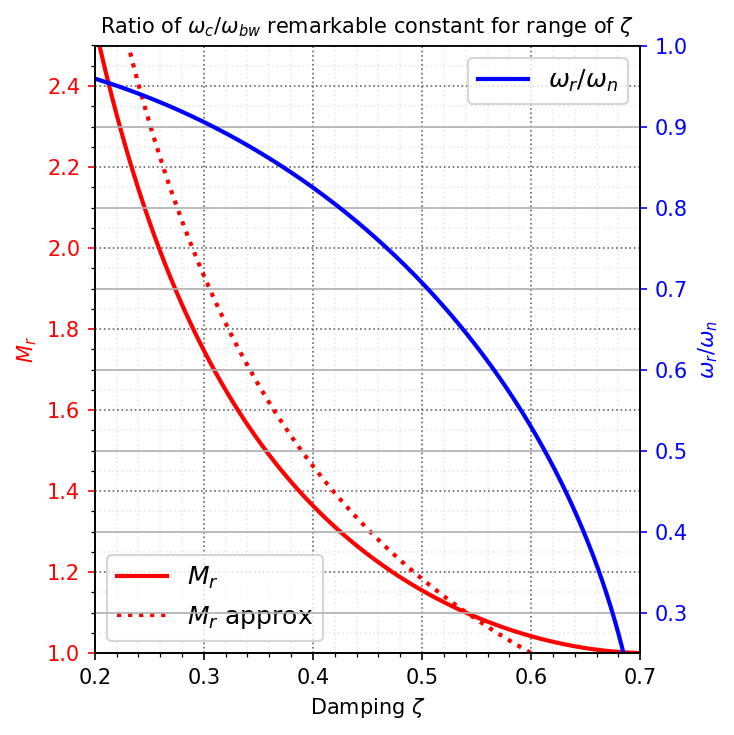

In [70]:
COLOR_left = "red"
COLOR_right = "blue"

fig, ax1 = plt.subplots(1,figsize=(5, 5),dpi=150)
ax2 = ax1.twinx()
z_range = np.arange(0.2,0.707,.001)

ax1.plot(z_range,f_peak(1,z_range)[1],color=COLOR_left,label=r"$M_r$")
PM = (100*z_range)*np.pi/180.
ax1.plot(z_range,1/(2*np.sin(PM/2.)),'r:',label=r'$M_r$ approx')
ax1.legend(loc = 3,fontsize=12, facecolor='white')
bm.nicegrid(ax1)

ax2.plot(z_range,f_peak(1,z_range)[0],color=COLOR_right,label=r"$\omega_r/\omega_n$")
ax2.legend(loc = 0,fontsize=12, facecolor='white')

plt.xlim([0.2,.7])
ax1.set_ylim([1.0,2.5])
ax1.set_ylabel(r"$M_r$", color=COLOR_left, fontsize=10)
ax1.tick_params(axis='y', colors=COLOR_left)
ax2.tick_params(axis='y', colors=COLOR_right)
ax2.set_ylabel(r"$\omega_r/\omega_n$", color=COLOR_right, fontsize=10)
ax2.set_ylim([0.25,1])
ax1.set_xlabel(r"Damping $\zeta$")
ax1.set_title(r"Ratio of $\omega_c/\omega_{bw}$ remarkable constant for range of $\zeta$ ")
plt.savefig("./figs/Mr_approx.pdf", dpi=600)
plt.show()


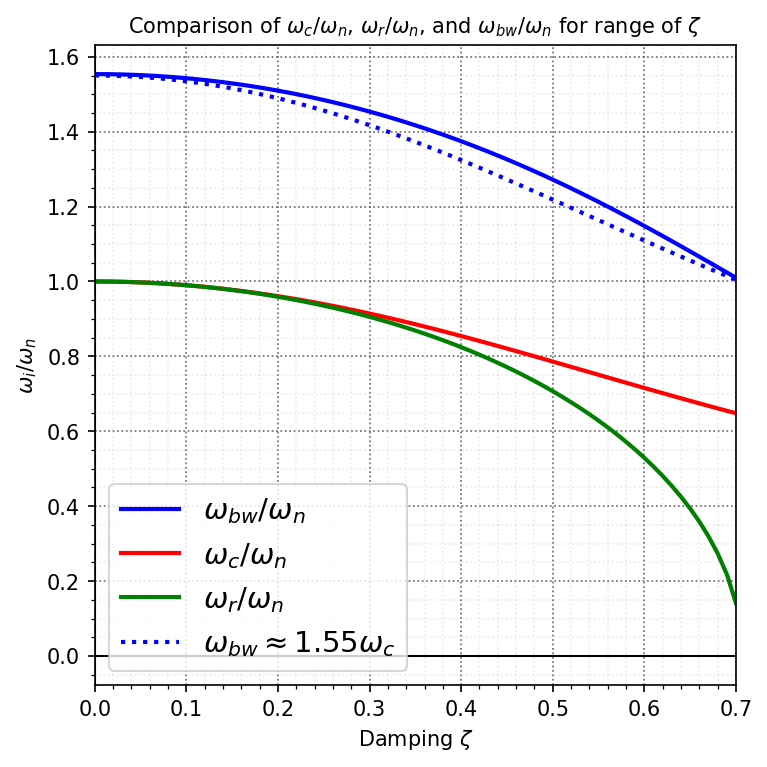

In [71]:
fig, ax = plt.subplots(1,figsize=(5, 5),dpi=150,constrained_layout = True)
z_range = np.arange(0,1/np.sqrt(2),.01)
plt.plot(z_range,f_wb(1,z_range),'b-',label=r"$\omega_{bw}/\omega_n$")
plt.plot(z_range,f_wc(1,z_range),'r-',label=r"$\omega_c/\omega_n$")
plt.plot(z_range,f_peak(1,z_range)[0],'g-',label=r"$\omega_r/\omega_n$")
plt.plot(z_range,1.55*f_wc(1,z_range),'b:',label=r"$\omega_{bw} \approx 1.55\omega_c$")
plt.legend(fontsize=14)
bm.nicegrid(ax)
plt.xlabel(r"Damping $\zeta$")
plt.ylabel(r"$\omega_i/\omega_n$")
ax.set_title(r"Comparison of $\omega_c/\omega_n$, $\omega_r/\omega_n$, and $\omega_{bw}/\omega_n$ for range of $\zeta$", fontsize=10)
plt.savefig("./figs/Freqs_approx.pdf", dpi=600)
plt.show()

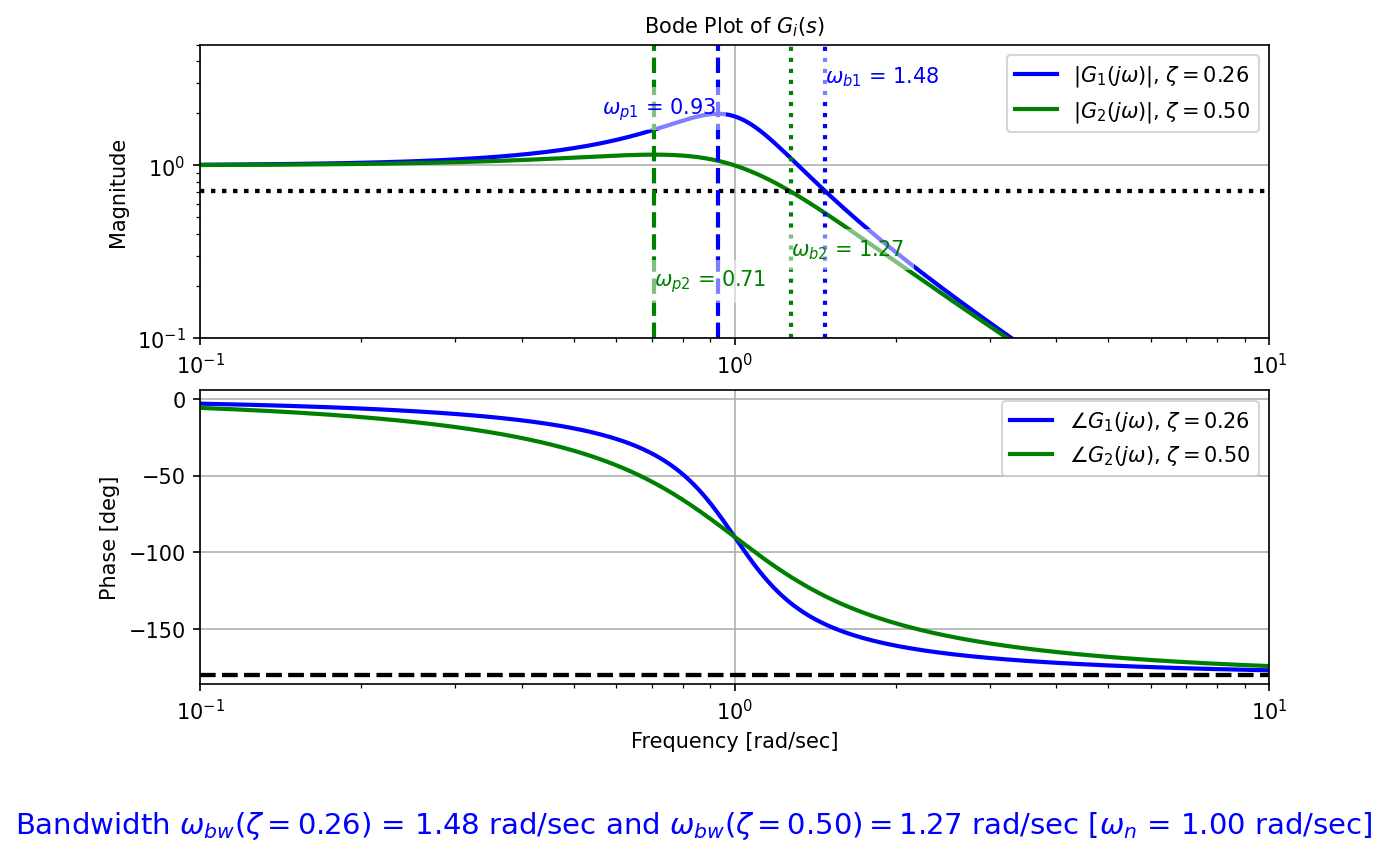

In [72]:
fig, ax = plt.subplots(2,1,figsize=(8, 5),dpi=150,constrained_layout = True)
zeta1 = 0.26
zeta2 = 0.5
w = np.logspace(-1,1,1000)
kwargs = {'color':'b','linewidth':2}
G1 = ct.tf([omega_n**2],[1, 2*zeta1*omega_n, omega_n**2]) 
Gfreq1 = G1(j*w)
Gm1, Gp1 = np.abs(Gfreq1), cm.pshift(np.angle(Gfreq1))*cm.r2d
kwargs = {'color':'g','linewidth':2}
G2 = ct.tf([omega_n**2],[1, 2*zeta2*omega_n, omega_n**2]) 
Gfreq2 = G2(j*w)
Gm2, Gp2 = np.abs(Gfreq2), cm.pshift(np.angle(Gfreq2))*cm.r2d

ax[0].loglog(w,Gm1,'b-',label=r'$|G_1(j\omega)|$, $\zeta={:3.2f}$'.format(zeta1))
ax[0].loglog(w,Gm2,'g-',label=r'$|G_2(j\omega)|$, $\zeta={:3.2f}$'.format(zeta2))
ax[0].axhline(y=mag_red_for_wb,c='k',ls=":")
ax[0].set_ylabel("Magnitude")
ax[0].set_title("Magnitude Plot")
ax[0].legend()
ax[1].semilogx(w,Gp1,'b-',label=r'$\angle G_1(j\omega)$, $\zeta={:3.2f}$'.format(zeta1))
ax[1].semilogx(w,Gp2,'g-',label=r'$\angle G_2(j\omega)$, $\zeta={:3.2f}$'.format(zeta2))
ax[1].axhline(y=-180,c='k',ls="--")
ax[1].set_xlabel("Frequency [rad/sec]")
ax[1].set_ylabel("Phase [deg]")
ax[1].legend()  

# Bandwidth calc - freq when is magnitude 0.7071?
wb1,II1 = cm.find_wc(w,G1,mag_red_for_wb)
wb2,II2 = cm.find_wc(w,G2,mag_red_for_wb)
wp1 = w[np.argmax(Gm1)]
wp2 = w[np.argmax(Gm2)]

props = dict(facecolor='white', alpha=0.5, linewidth=0)
ax1,ax2 = plt.gcf().axes
ax1.set_title("Bode Plot of $G_i(s)$")
ax1.axhline(y=1/np.sqrt(2),c='k',ls=":")
ax2.axhline(y=-180,c='k',ls="--")
ax1.axvline(x=wb1,c='b',ls=":")
ax1.axvline(x=wp1,c='b',ls="--")
ax1.axvline(x=wb2,c='g',ls=":")
ax1.axvline(x=wp2,c='g',ls="--")
ax1.text(wb1,3,r'$\omega_{{b1}}$ = {:3.2f} '.format(wb1),color='b',bbox=props)
ax1.text(wb2,.3,r'$\omega_{{b2}}$ = {:3.2f} '.format(wb2),color='g',bbox=props)
ax1.text(wp1,2,r'$\omega_{{p1}}$ = {:3.2f} '.format(wp1),color='b',horizontalalignment='right',bbox=props)
ax1.text(wp2,.2,r'$\omega_{{p2}}$ = {:3.2f} '.format(wp2),color='g',bbox=props)
ax1.set_ylim([.1,5])
cm.caption(r"Bandwidth $\omega_{{bw}}(\zeta={:3.2f})$ = {:4.2f} rad/sec and $\omega_{{bw}}(\zeta={:3.2f})={:4.2f}$ rad/sec [$\omega_n$ = {:4.2f} rad/sec]".format(zeta1,wb1,zeta2,wb2,omega_n),fig,yloc=-.1)

# How much Phase? (18-10)

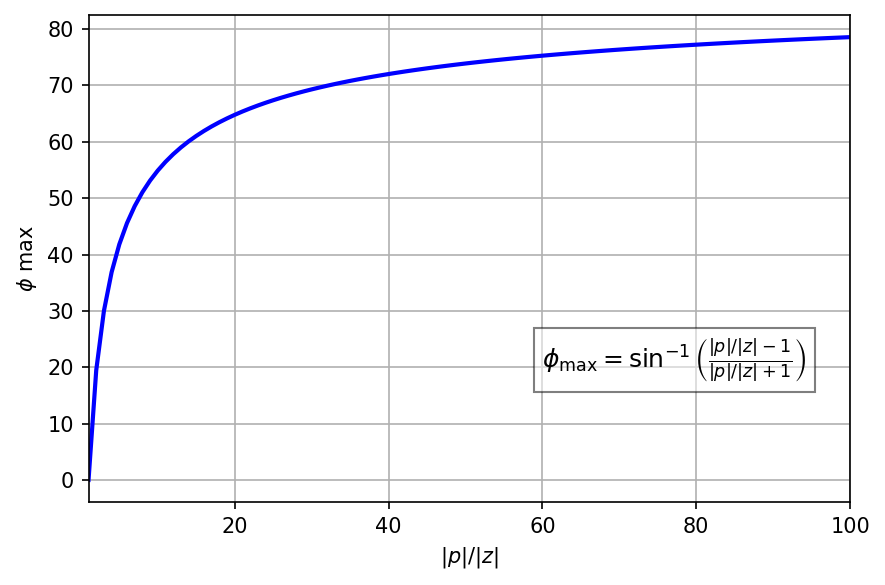

In [73]:
fig, ax = plt.subplots(1,figsize=(6, 4),dpi=150)
pz = np.linspace(1,100,100)
phi_max = np.arcsin((pz-1)/(pz+1))
plt.plot(pz,phi_max*cm.r2d,'b')
plt.ylabel(r"$\phi$ max")
plt.xlabel(r"$|p|/|z|$")
plt.savefig("./figs/How_much_rhase.pdf", dpi=600)
plt.text(60, 20, r'$\phi_{\max} = \sin^{-1} \left(\frac{|p|/|z|-1}{|p|/|z|+1}\right)$', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))
plt.show()